In [ ]:
# Modélisation et validation

## Contrat expérimental

- TRAIN : steps 1 à 323
- VALIDATION : steps 324 à 377
- TEST : steps 378 à 743, non utilisé

## Règles

- Les modèles sont entraînés uniquement sur TRAIN.
- Les décisions de modèle, seuil, hyperparamètres et calibration sont prises sur VALIDATION.
- Le TEST reste fermé jusqu'à l'évaluation finale.
- Les variables post-transaction restent interdites.

## Baselines

- B0 : prévalence de la fraude
- B1 : classement par montant
- B2 : règle de proximité du montant avec le solde disponible
- B3 : régression logistique
- M1 : XGBoost

In [1]:
# Imports
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
)

from src.features import (
    build_static_features,
    prepare_xgb_matrix,
)

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
)

In [2]:
CURRENT = Path.cwd()

if (CURRENT / "data").exists():
    ROOT = CURRENT
else:
    ROOT = CURRENT.parent

TRAIN_PATH = ROOT / "data" / "processed" / "train.parquet"
VALIDATION_PATH = ROOT / "data" / "processed" / "validation.parquet"

assert TRAIN_PATH.exists()
assert VALIDATION_PATH.exists()

print(ROOT)

C:\Users\Emmanuel\Documents\Professionnel\Formations\DIT\fraude-mobile-money


In [3]:
# Charger Train et Validation
columns = [
    "step",
    "type",
    "amount",
    "oldbalance_org",
    "oldbalance_dest",
    "is_fraud",
]

train = pd.read_parquet(
    TRAIN_PATH,
    columns=columns,
)

validation = pd.read_parquet(
    VALIDATION_PATH,
    columns=columns,
)

In [4]:
# Vérifications
print("TRAIN")
print(train.shape)
print(train["step"].min(), train["step"].max())
print(train["is_fraud"].sum())
print(train["is_fraud"].mean())

print()

print("VALIDATION")
print(validation.shape)
print(validation["step"].min(), validation["step"].max())
print(validation["is_fraud"].sum())
print(validation["is_fraud"].mean())

TRAIN
(4463587, 6)
1 323
3643
0.0008161597387930379

VALIDATION
(943289, 6)
324 377
560
0.00059366747624535


In [5]:
assert len(train) == 4_463_587
assert len(validation) == 943_289

assert train["step"].min() == 1
assert train["step"].max() == 323

assert validation["step"].min() == 324
assert validation["step"].max() == 377

assert train["is_fraud"].sum() == 3_643
assert validation["is_fraud"].sum() == 560

print("Contrat temporel : OK")

Contrat temporel : OK


In [6]:
# Construction des features S0
X_train = build_static_features(train)
X_val = build_static_features(validation)

y_train = train["is_fraud"].astype("int8")
y_val = validation["is_fraud"].astype("int8")

In [7]:
# Vérification
display(X_train.head())

print()
print("NaN TRAIN")
display(X_train.isna().sum())

print()
print("NaN VALIDATION")
display(X_val.isna().sum())

,log_amount,log_oldbalance_org,log_oldbalance_dest,initial_balance_zero,dest_balance_zero,log_ecart_vidage,type
0,9.194276,12.044359,0.000000,0,1,0.663804,PAYMENT
1,7.531166,9.964112,0.000000,0,1,0.648288,PAYMENT
2,5.204007,5.204007,0.000000,0,1,0.000000,TRANSFER
3,5.204007,5.204007,9.960954,0,0,0.000000,CASH_OUT
4,9.364703,10.634773,0.000000,0,1,0.541862,PAYMENT



NaN TRAIN


log_amount                    0
log_oldbalance_org            0
log_oldbalance_dest           0
initial_balance_zero          0
dest_balance_zero             0
log_ecart_vidage        1481355
type                          0
dtype: int64


NaN VALIDATION


log_amount                   0
log_oldbalance_org           0
log_oldbalance_dest          0
initial_balance_zero         0
dest_balance_zero            0
log_ecart_vidage        318556
type                         0
dtype: int64

In [8]:
assert (
    X_train["log_ecart_vidage"].isna()
    ==
    (X_train["initial_balance_zero"] == 1)
).all()

assert (
    X_val["log_ecart_vidage"].isna()
    ==
    (X_val["initial_balance_zero"] == 1)
).all()

print("Features S0 : OK")

Features S0 : OK


In [9]:
# Baseline de prévalence
val_prevalence = y_val.mean()

print(
    f"Prévalence Validation : "
    f"{val_prevalence:.6%}"
)

Prévalence Validation : 0.059367%


In [10]:
# Precision@K / Recall@K
def precision_recall_at_k(
    y_true,
    scores,
    k,
):
    result = pd.DataFrame({
        "y": np.asarray(y_true),
        "score": np.asarray(scores),
    })

    result = result.sort_values(
        "score",
        ascending=False,
        kind="mergesort",
    )

    top = result.head(k)

    tp = int(top["y"].sum())

    precision = tp / len(top)

    total_positive = int(result["y"].sum())

    recall = (
        tp / total_positive
        if total_positive > 0
        else 0.0
    )

    return {
        "k": k,
        "tp": tp,
        "precision": precision,
        "recall": recall,
    }

In [11]:
# Montant seul
amount_score = validation["amount"].to_numpy()

In [12]:
# Average Precision
ap_amount = average_precision_score(
    y_val,
    amount_score,
)

print(f"AP montant : {ap_amount:.6f}")
print(
    f"Prévalence : {val_prevalence:.6f}"
)
print(
    f"Lift AP : {ap_amount / val_prevalence:.2f}x"
)

AP montant : 0.004373
Prévalence : 0.000594
Lift AP : 7.37x


In [13]:
# Precision@K / Recall@K du montant
amount_at_k = pd.DataFrame([
    precision_recall_at_k(
        y_val,
        amount_score,
        k,
    )
    for k in [
        100,
        500,
        1_000,
        5_000,
        10_000,
    ]
])

amount_at_k

,k,tp,precision,recall
0,100,0,0.0000,0.000000
1,500,0,0.0000,0.000000
2,1000,0,0.0000,0.000000
3,5000,58,0.0116,0.103571
4,10000,82,0.0082,0.146429


In [14]:
# ecart_vidage brut
def compute_ecart_vidage(df):
    amount = df["amount"].astype(float)
    balance = df["oldbalance_org"].astype(float)

    return pd.Series(
        np.where(
            balance > 0,
            np.abs(
                amount / balance - 1.0
            ),
            np.nan,
        ),
        index=df.index,
        name="ecart_vidage",
    )

In [15]:
val_ecart = compute_ecart_vidage(
    validation
)

val_ecart.describe()

count    6.247330e+05
mean     1.529726e+02
std      5.045452e+03
min      0.000000e+00
25%      8.056798e-01
50%      9.819535e-01
75%      6.562121e+00
max      1.789023e+06
Name: ecart_vidage, dtype: float64

In [16]:
# Vérifier les soldes nuls sur Validation
val_zero_balance = (
    validation["oldbalance_org"] == 0
)

zero_balance_validation = pd.DataFrame({
    "transactions": (
        validation.groupby("is_fraud")
        .size()
    ),
    "solde_initial_nul": (
        validation.assign(
            zero=val_zero_balance.astype("int8")
        )
        .groupby("is_fraud")["zero"]
        .sum()
    ),
})

zero_balance_validation[
    "part_solde_initial_nul"
] = (
    zero_balance_validation[
        "solde_initial_nul"
    ]
    /
    zero_balance_validation[
        "transactions"
    ]
)

zero_balance_validation

,transactions,solde_initial_nul,part_solde_initial_nul
is_fraud,,,
0,942729,318556,0.337908
1,560,0,0.000000


In [17]:
# seuils ecart_vidage
epsilons = [
    0.0001,
    0.0005,
    0.001,
    0.002,
    0.005,
    0.01,
    0.02,
    0.05,
    0.10,
]

results = []

for eps in epsilons:
    pred = (
        val_ecart.notna()
        & (val_ecart <= eps)
    )

    tp = int(
        (
            pred
            & (y_val == 1)
        ).sum()
    )

    fp = int(
        (
            pred
            & (y_val == 0)
        ).sum()
    )

    fn = int(
        (
            (~pred)
            & (y_val == 1)
        ).sum()
    )

    alerts = tp + fp

    precision = (
        tp / alerts
        if alerts > 0
        else 0
    )

    recall = (
        tp / (tp + fn)
        if (tp + fn) > 0
        else 0
    )

    results.append({
        "epsilon": eps,
        "alertes": alerts,
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "precision": precision,
        "recall": recall,
        "taux_alerte": (
            alerts / len(validation)
        ),
    })

rule_results = pd.DataFrame(results)

rule_results

,epsilon,alertes,tp,fp,fn,precision,recall,taux_alerte
0,0.0001,566,555,11,5,0.980565,0.991071,0.000600
1,0.0005,614,555,59,5,0.903909,0.991071,0.000651
2,0.0010,683,555,128,5,0.812592,0.991071,0.000724
3,0.0020,833,555,278,5,0.666267,0.991071,0.000883
4,0.0050,1275,555,720,5,0.435294,0.991071,0.001352
5,0.0100,2013,555,1458,5,0.275708,0.991071,0.002134
6,0.0200,3424,555,2869,5,0.162091,0.991071,0.003630
7,0.0500,7867,555,7312,5,0.070548,0.991071,0.008340
8,0.1000,15053,556,14497,4,0.036936,0.992857,0.015958


In [18]:
# Affichage plus lisible
rule_display = rule_results.copy()

for col in [
    "precision",
    "recall",
    "taux_alerte",
]:
    rule_display[col] = (
        rule_display[col] * 100
    )

rule_display

,epsilon,alertes,tp,fp,fn,precision,recall,taux_alerte
0,0.0001,566,555,11,5,98.056537,99.107143,0.060003
1,0.0005,614,555,59,5,90.390879,99.107143,0.065091
2,0.0010,683,555,128,5,81.259151,99.107143,0.072406
3,0.0020,833,555,278,5,66.626651,99.107143,0.088308
4,0.0050,1275,555,720,5,43.529412,99.107143,0.135165
5,0.0100,2013,555,1458,5,27.570790,99.107143,0.213402
6,0.0200,3424,555,2869,5,16.209112,99.107143,0.362985
7,0.0500,7867,555,7312,5,7.054786,99.107143,0.833997
8,0.1000,15053,556,14497,4,3.693616,99.285714,1.595799


In [19]:
# Nombre d’alertes par 10 000 transactions
rule_results[
    "alertes_par_10000"
] = (
    rule_results["taux_alerte"]
    * 10_000
)

rule_results[
    [
        "epsilon",
        "alertes",
        "alertes_par_10000",
        "precision",
        "recall",
    ]
]

,epsilon,alertes,alertes_par_10000,precision,recall
0,0.0001,566,6.000282,0.980565,0.991071
1,0.0005,614,6.509140,0.903909,0.991071
2,0.0010,683,7.240623,0.812592,0.991071
3,0.0020,833,8.830804,0.666267,0.991071
4,0.0050,1275,13.516536,0.435294,0.991071
5,0.0100,2013,21.340226,0.275708,0.991071
6,0.0200,3424,36.298526,0.162091,0.991071
7,0.0500,7867,83.399679,0.070548,0.991071
8,0.1000,15053,159.579938,0.036936,0.992857


In [20]:
# Comparer explicitement Train et Validation
rule_results.loc[
    rule_results["epsilon"] == 0.001
]

,epsilon,alertes,tp,fp,fn,precision,recall,taux_alerte,alertes_par_10000
2,0.001,683,555,128,5,0.812592,0.991071,0.000724,7.240623


In [21]:
# Ranking continu par proximité du vidage
ecart_score = np.where(
    val_ecart.notna(),
    -np.log1p(val_ecart),
    -np.inf,
)

In [22]:
ecart_at_k = pd.DataFrame([
    precision_recall_at_k(
        y_val,
        ecart_score,
        k,
    )
    for k in [
        100,
        500,
        1_000,
        5_000,
        10_000,
    ]
])

ecart_at_k

,k,tp,precision,recall
0,100,100,1.0000,0.178571
1,500,500,1.0000,0.892857
2,1000,555,0.5550,0.991071
3,5000,555,0.1110,0.991071
4,10000,556,0.0556,0.992857


In [23]:
# Synthèse
baseline_summary = pd.DataFrame({
    "baseline": [
        "B0 - prévalence",
        "B1 - montant",
    ],
    "average_precision": [
        val_prevalence,
        ap_amount,
    ],
})

baseline_summary[
    "lift_vs_prevalence"
] = (
    baseline_summary[
        "average_precision"
    ]
    / val_prevalence
)

baseline_summary

,baseline,average_precision,lift_vs_prevalence
0,B0 - prévalence,0.000594,1.00000
1,B1 - montant,0.004373,7.36594


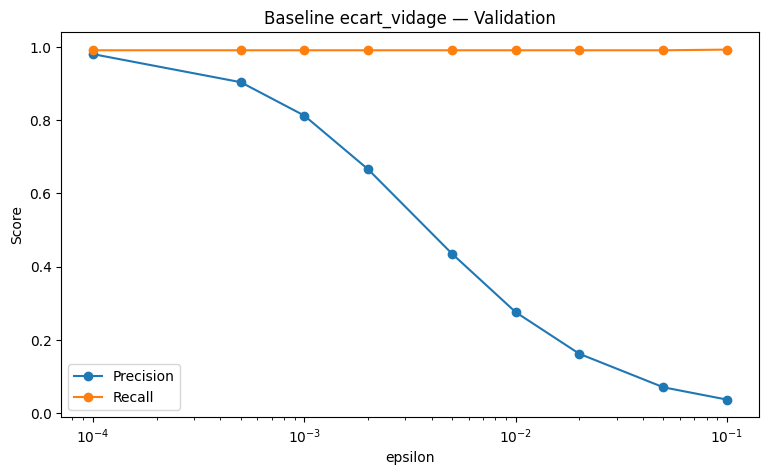

In [24]:
# Graphique de la règle ecart_vidage
plt.figure(figsize=(9, 5))

plt.plot(
    rule_results["epsilon"],
    rule_results["precision"],
    marker="o",
    label="Precision",
)

plt.plot(
    rule_results["epsilon"],
    rule_results["recall"],
    marker="o",
    label="Recall",
)

plt.xscale("log")

plt.xlabel("epsilon")
plt.ylabel("Score")
plt.title(
    "Baseline ecart_vidage — Validation"
)
plt.legend()

plt.show()

In [25]:
tie_diagnostic = pd.DataFrame({
    "is_fraud": y_val.to_numpy(),
    "ecart_vidage": val_ecart.to_numpy(),
})

tie_diagnostic["ecart_exact_zero"] = (
    tie_diagnostic["ecart_vidage"] == 0
)

exact_zero_summary = (
    tie_diagnostic
    .groupby("is_fraud")
    .agg(
        transactions=("is_fraud", "size"),
        ecart_exact_zero=(
            "ecart_exact_zero",
            "sum",
        ),
    )
)

exact_zero_summary[
    "part_exact_zero"
] = (
    exact_zero_summary["ecart_exact_zero"]
    / exact_zero_summary["transactions"]
)

exact_zero_summary

,transactions,ecart_exact_zero,part_exact_zero
is_fraud,,,
0,942729,0,0.000000
1,560,555,0.991071


In [26]:
tie_diagnostic.loc[
    tie_diagnostic["ecart_vidage"].notna(),
    "ecart_vidage"
].value_counts().head(20)

ecart_vidage
0.000000         555
873.355163         2
622.986023         2
588234.294118      2
0.844380           2
56817.181818       2
3.763340           2
904.797101         2
0.947451           1
0.850300           1
1.732021           1
12.762993          1
0.464465           1
18.773100          1
4.770532           1
881.863385         1
1.786108           1
0.915179           1
1.729959           1
0.668254           1
Name: count, dtype: int64

In [27]:
# Precision@K pour scores ex æquo
def tie_aware_at_k(
    y_true,
    scores,
    k,
):
    data = pd.DataFrame({
        "y": np.asarray(y_true),
        "score": np.asarray(scores),
    })

    groups = (
        data.groupby(
            "score",
            dropna=False,
        )["y"]
        .agg(
            n="size",
            positives="sum",
        )
        .sort_index(
            ascending=False,
        )
    )

    remaining = k
    fixed_tp = 0

    min_tp = 0
    max_tp = 0
    expected_tp = 0.0

    for _, row in groups.iterrows():

        n = int(row["n"])
        positives = int(row["positives"])
        negatives = n - positives

        if remaining >= n:
            fixed_tp += positives
            remaining -= n

            if remaining == 0:
                min_tp = fixed_tp
                max_tp = fixed_tp
                expected_tp = float(
                    fixed_tp
                )
                break

        else:
            slots = remaining

            min_additional = max(
                0,
                slots - negatives,
            )

            max_additional = min(
                slots,
                positives,
            )

            expected_additional = (
                slots
                * positives
                / n
            )

            min_tp = (
                fixed_tp
                + min_additional
            )

            max_tp = (
                fixed_tp
                + max_additional
            )

            expected_tp = (
                fixed_tp
                + expected_additional
            )

            break

    total_positive = np.sum(y_true)

    return {
        "k": k,

        "precision_min": (
            min_tp / k
        ),

        "precision_expected": (
            expected_tp / k
        ),

        "precision_max": (
            max_tp / k
        ),

        "recall_expected": (
            expected_tp
            / total_positive
        ),
    }

In [28]:
ecart_tie_aware = pd.DataFrame([
    tie_aware_at_k(
        y_val,
        ecart_score,
        k,
    )
    for k in [
        100,
        500,
        1_000,
        5_000,
        10_000,
    ]
])

ecart_tie_aware

,k,precision_min,precision_expected,precision_max,recall_expected
0,100,1.0000,1.0000,1.0000,0.178571
1,500,1.0000,1.0000,1.0000,0.892857
2,1000,0.5550,0.5550,0.5550,0.991071
3,5000,0.1110,0.1110,0.1110,0.991071
4,10000,0.0556,0.0556,0.0556,0.992857


In [29]:
# Validation
epsilon_reference = 0.0001

caught = (
    val_ecart.notna()
    & (
        val_ecart
        <= epsilon_reference
    )
)

missed_frauds = validation.loc[
    (y_val == 1)
    & (~caught),
    [
        "step",
        "type",
        "amount",
        "oldbalance_org",
        "oldbalance_dest",
        "is_fraud",
    ],
].copy()

missed_frauds[
    "ecart_vidage"
] = val_ecart.loc[
    missed_frauds.index
]

missed_frauds[
    "ecart_pct"
] = (
    missed_frauds[
        "ecart_vidage"
    ]
    * 100
)

missed_frauds

,step,type,amount,oldbalance_org,oldbalance_dest,is_fraud,ecart_vidage,ecart_pct
569610,354,TRANSFER,10000000.0,19299230.13,0.0,1,0.481845,48.184462
696044,357,TRANSFER,10000000.0,10653151.55,0.0,1,0.061311,6.131064
715424,359,TRANSFER,10000000.0,12056779.24,0.0,1,0.170591,17.059110
724231,362,TRANSFER,10000000.0,17677120.59,0.0,1,0.434297,43.429701
757563,370,TRANSFER,10000000.0,11653144.10,0.0,1,0.141862,14.186250


In [30]:
# Pipeline logistique
numeric_features_b3a = [
    "log_amount",
    "log_oldbalance_org",
    "initial_balance_zero",
    "log_ecart_vidage",
    "log_oldbalance_dest",
    "dest_balance_zero",
]

categorical_features = [
    "type",
]

In [31]:
# Expliquer pourquoi la valeur est absente

numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="constant",
            fill_value=-1.0,
        ),
    ),
    (
        "scaler",
        StandardScaler(),
    ),
])

categorical_pipeline = Pipeline([
    (
        "onehot",
        OneHotEncoder(
            handle_unknown="ignore",
        ),
    ),
])

preprocessor_b3a = ColumnTransformer([
    (
        "numeric",
        numeric_pipeline,
        numeric_features_b3a,
    ),
    (
        "categorical",
        categorical_pipeline,
        categorical_features,
    ),
])

In [32]:
# Modèle B3a
b3a = Pipeline([
    (
        "preprocessor",
        preprocessor_b3a,
    ),
    (
        "model",
        LogisticRegression(
            class_weight="balanced",
            max_iter=1000,
            solver="lbfgs",
            random_state=42,
        ),
    ),
])

In [33]:
b3a.fit(
    X_train,
    y_train,
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value=-1.0,
                                                                                 strategy='constant')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['log_amount',
                                                   'log_oldbalance_org',
                                                   'initial_balance_zero',
                                                   'log_ecart_vidage',
                                                   'log_oldbalance_dest',
                                                   'dest_balance_zero']),
                                                 ('categorical',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['type'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [34]:
# Évaluer B3a
b3a_score = b3a.predict_proba(
    X_val
)[:, 1]

b3a_ap = average_precision_score(
    y_val,
    b3a_score,
)

b3a_roc_auc = roc_auc_score(
    y_val,
    b3a_score,
)

print(
    f"B3a AP      : {b3a_ap:.6f}"
)

print(
    f"B3a ROC-AUC : {b3a_roc_auc:.6f}"
)

print(
    f"Lift AP     : "
    f"{b3a_ap / val_prevalence:.2f}x"
)

B3a AP      : 0.688248
B3a ROC-AUC : 0.999208
Lift AP     : 1159.31x


In [35]:
b3a_at_k = pd.DataFrame([
    precision_recall_at_k(
        y_val,
        b3a_score,
        k,
    )
    for k in [
        100,
        500,
        555,
        560,
        1_000,
        5_000,
        10_000,
    ]
])

b3a_at_k

,k,tp,precision,recall
0,100,100,1.000000,0.178571
1,500,339,0.678000,0.605357
2,555,345,0.621622,0.616071
3,560,346,0.617857,0.617857
4,1000,385,0.385000,0.687500
5,5000,542,0.108400,0.967857
6,10000,560,0.056000,1.000000


In [36]:
# Vérifier spécifiquement les cinq fraudes atypiques
validation_scores = validation[
    [
        "step",
        "type",
        "amount",
        "oldbalance_org",
        "oldbalance_dest",
        "is_fraud",
    ]
].copy()

validation_scores[
    "b3a_score"
] = b3a_score

validation_scores[
    "rank_b3a"
] = (
    validation_scores[
        "b3a_score"
    ]
    .rank(
        method="min",
        ascending=False,
    )
    .astype(int)
)

In [37]:
missed_b3a = validation_scores.loc[
    missed_frauds.index,
    [
        "step",
        "type",
        "amount",
        "oldbalance_org",
        "oldbalance_dest",
        "b3a_score",
        "rank_b3a",
    ],
].sort_values(
    "rank_b3a"
)

missed_b3a

,step,type,amount,oldbalance_org,oldbalance_dest,b3a_score,rank_b3a
696044,357,TRANSFER,10000000.0,10653151.55,0.0,0.998628,79
757563,370,TRANSFER,10000000.0,11653144.10,0.0,0.996030,298
715424,359,TRANSFER,10000000.0,12056779.24,0.0,0.994319,386
724231,362,TRANSFER,10000000.0,17677120.59,0.0,0.906617,5633
569610,354,TRANSFER,10000000.0,19299230.13,0.0,0.860770,7395


In [38]:
# Modèle B3b sans ecart_vidage
numeric_features_b3b = [
    "log_amount",
    "log_oldbalance_org",
    "initial_balance_zero",
    "log_oldbalance_dest",
    "dest_balance_zero",
]

In [39]:
preprocessor_b3b = ColumnTransformer([
    (
        "numeric",
        numeric_pipeline,
        numeric_features_b3b,
    ),
    (
        "categorical",
        categorical_pipeline,
        categorical_features,
    ),
])

b3b = Pipeline([
    (
        "preprocessor",
        preprocessor_b3b,
    ),
    (
        "model",
        LogisticRegression(
            class_weight="balanced",
            max_iter=1000,
            solver="lbfgs",
            random_state=42,
        ),
    ),
])

In [40]:
# Entraînement
b3b.fit(
    X_train,
    y_train,
)

b3b_score = b3b.predict_proba(
    X_val
)[:, 1]

In [41]:
# On évalue
b3b_ap = average_precision_score(
    y_val,
    b3b_score,
)

b3b_roc_auc = roc_auc_score(
    y_val,
    b3b_score,
)

print(
    f"B3b AP      : {b3b_ap:.6f}"
)

print(
    f"B3b ROC-AUC : {b3b_roc_auc:.6f}"
)

print(
    f"Lift AP     : "
    f"{b3b_ap / val_prevalence:.2f}x"
)

B3b AP      : 0.018086
B3b ROC-AUC : 0.979467
Lift AP     : 30.46x


In [42]:
b3b_at_k = pd.DataFrame([
    precision_recall_at_k(
        y_val,
        b3b_score,
        k,
    )
    for k in [
        100,
        500,
        555,
        560,
        1_000,
        5_000,
        10_000,
    ]
])

b3b_at_k

,k,tp,precision,recall
0,100,0,0.000000,0.000000
1,500,0,0.000000,0.000000
2,555,1,0.001802,0.001786
3,560,1,0.001786,0.001786
4,1000,2,0.002000,0.003571
5,5000,120,0.024000,0.214286
6,10000,236,0.023600,0.421429


In [43]:
# Comparaison synthétique
logistic_summary = pd.DataFrame({
    "modele": [
        "B1 - montant",
        "B3a - LogReg S0",
        "B3b - LogReg sans ecart",
    ],
    "average_precision": [
        ap_amount,
        b3a_ap,
        b3b_ap,
    ],
})

logistic_summary[
    "lift_vs_prevalence"
] = (
    logistic_summary[
        "average_precision"
    ]
    / val_prevalence
)

logistic_summary

,modele,average_precision,lift_vs_prevalence
0,B1 - montant,0.004373,7.365940
1,B3a - LogReg S0,0.688248,1159.314841
2,B3b - LogReg sans ecart,0.018086,30.464591


In [44]:
# On mesure l’AP de B2a
exact_drain_score = (
    val_ecart.eq(0)
    .astype(float)
)

b2a_ap = average_precision_score(
    y_val,
    exact_drain_score,
)

print(
    f"B2a Average Precision : {b2a_ap:.6f}"
)

print(
    f"B2a Lift : "
    f"{b2a_ap / val_prevalence:.2f}x"
)

B2a Average Precision : 0.991077
B2a Lift : 1669.41x


In [45]:
# XGBoost S0
from xgboost import XGBClassifier

# prepare_xgb_matrix importée depuis src.features

In [46]:
X_train_xgb = prepare_xgb_matrix(
    X_train
)

X_val_xgb = prepare_xgb_matrix(
    X_val,
    train_columns=X_train_xgb.columns,
)

print(X_train_xgb.shape)
print(X_val_xgb.shape)

print(X_train_xgb.dtypes)

(4463587, 11)
(943289, 11)
log_amount              float32
log_oldbalance_org      float32
log_oldbalance_dest     float32
initial_balance_zero    float32
dest_balance_zero       float32
log_ecart_vidage        float32
type_CASH_IN            float32
type_CASH_OUT           float32
type_DEBIT              float32
type_PAYMENT            float32
type_TRANSFER           float32
dtype: object


In [47]:
# XGBoost complet
m1a = XGBClassifier(
    n_estimators=600,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    reg_lambda=1.0,
    objective="binary:logistic",
    eval_metric="aucpr",
    tree_method="hist",
    n_jobs=-1,
    random_state=42,
)

m1a.fit(
    X_train_xgb,
    y_train,
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='aucpr', feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=5, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=600, n_jobs=-1,
              num_parallel_tree=None, random_state=42, ...)

In [48]:
# Évaluation XGBoost complet
m1a_score = m1a.predict_proba(
    X_val_xgb
)[:, 1]

m1a_ap = average_precision_score(
    y_val,
    m1a_score,
)

m1a_roc_auc = roc_auc_score(
    y_val,
    m1a_score,
)

print(
    f"M1a AP      : {m1a_ap:.6f}"
)

print(
    f"M1a ROC-AUC : {m1a_roc_auc:.6f}"
)

print(
    f"M1a Lift    : "
    f"{m1a_ap / val_prevalence:.2f}x"
)

M1a AP      : 0.901610
M1a ROC-AUC : 0.999908
M1a Lift    : 1518.71x


In [49]:
m1a_at_k = pd.DataFrame([
    precision_recall_at_k(
        y_val,
        m1a_score,
        k,
    )
    for k in [
        100,
        500,
        555,
        560,
        1_000,
        5_000,
        10_000,
    ]
])

m1a_at_k

,k,tp,precision,recall
0,100,100,1.000000,0.178571
1,500,436,0.872000,0.778571
2,555,452,0.814414,0.807143
3,560,453,0.808929,0.808929
4,1000,518,0.518000,0.925000
5,5000,560,0.112000,1.000000
6,10000,560,0.056000,1.000000


In [50]:
# Classement des cinq fraudes atypiques
validation_scores[
    "m1a_score"
] = m1a_score

validation_scores[
    "rank_m1a"
] = (
    validation_scores["m1a_score"]
    .rank(
        method="min",
        ascending=False,
    )
    .astype(int)
)

missed_m1a = validation_scores.loc[
    missed_frauds.index,
    [
        "step",
        "type",
        "amount",
        "oldbalance_org",
        "oldbalance_dest",
        "m1a_score",
        "rank_m1a",
    ],
].sort_values(
    "rank_m1a"
)

missed_m1a

,step,type,amount,oldbalance_org,oldbalance_dest,m1a_score,rank_m1a
696044,357,TRANSFER,10000000.0,10653151.55,0.0,0.970695,194
724231,362,TRANSFER,10000000.0,17677120.59,0.0,0.969973,202
715424,359,TRANSFER,10000000.0,12056779.24,0.0,0.969527,203
757563,370,TRANSFER,10000000.0,11653144.10,0.0,0.969527,203
569610,354,TRANSFER,10000000.0,19299230.13,0.0,0.968901,205


In [51]:
# XGBoost sans ecart_vidage
xgb_without_ecart = [
    col
    for col in X_train_xgb.columns
    if col != "log_ecart_vidage"
]

m1b = XGBClassifier(
    n_estimators=600,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    reg_lambda=1.0,
    objective="binary:logistic",
    eval_metric="aucpr",
    tree_method="hist",
    n_jobs=-1,
    random_state=42,
)

m1b.fit(
    X_train_xgb[xgb_without_ecart],
    y_train,
)

m1b_score = m1b.predict_proba(
    X_val_xgb[xgb_without_ecart]
)[:, 1]

In [52]:
# On garde les mêmes métriques
m1b_ap = average_precision_score(
    y_val,
    m1b_score,
)

m1b_roc_auc = roc_auc_score(
    y_val,
    m1b_score,
)

print(
    f"M1b AP      : {m1b_ap:.6f}"
)

print(
    f"M1b ROC-AUC : {m1b_roc_auc:.6f}"
)

print(
    f"M1b Lift    : "
    f"{m1b_ap / val_prevalence:.2f}x"
)

M1b AP      : 0.757170
M1b ROC-AUC : 0.999293
M1b Lift    : 1275.41x


In [53]:
m1b_at_k = pd.DataFrame([
    precision_recall_at_k(
        y_val,
        m1b_score,
        k,
    )
    for k in [
        100,
        500,
        555,
        560,
        1_000,
        5_000,
        10_000,
    ]
])

m1b_at_k

,k,tp,precision,recall
0,100,100,1.000000,0.178571
1,500,391,0.782000,0.698214
2,555,400,0.720721,0.714286
3,560,401,0.716071,0.716071
4,1000,434,0.434000,0.775000
5,5000,537,0.107400,0.958929
6,10000,558,0.055800,0.996429


In [54]:
# la règle est optimale pour le motif dominant de PaySim ; XGBoost semble utile pour traiter les exceptions.

SyntaxError: invalid syntax (3679956812.py, line 1)

In [55]:
# Test hybride B2a + M1a
exact_drain_val = (
    val_ecart.eq(0)
)

hybrid_m1a_score = np.where(
    exact_drain_val,
    2.0 + m1a_score,
    m1a_score,
)

In [56]:
h1_ap = average_precision_score(
    y_val,
    hybrid_m1a_score,
)

print(
    f"H1 AP   : {h1_ap:.6f}"
)

print(
    f"H1 Lift : "
    f"{h1_ap / val_prevalence:.2f}x"
)

H1 AP   : 1.000000
H1 Lift : 1684.44x


In [57]:
h1_at_k = pd.DataFrame([
    precision_recall_at_k(
        y_val,
        hybrid_m1a_score,
        k,
    )
    for k in [
        100,
        500,
        555,
        556,
        557,
        558,
        559,
        560,
        1_000,
        5_000,
    ]
])

h1_at_k

,k,tp,precision,recall
0,100,100,1.000,0.178571
1,500,500,1.000,0.892857
2,555,555,1.000,0.991071
3,556,556,1.000,0.992857
4,557,557,1.000,0.994643
5,558,558,1.000,0.996429
6,559,559,1.000,0.998214
7,560,560,1.000,1.000000
8,1000,560,0.560,1.000000
9,5000,560,0.112,1.000000


In [58]:
# Mesurer leur rang résiduel réel
residual_mask = ~exact_drain_val

residual = validation.loc[
    residual_mask,
    [
        "step",
        "type",
        "amount",
        "oldbalance_org",
        "oldbalance_dest",
        "is_fraud",
    ],
].copy()

residual[
    "m1a_score"
] = m1a_score[
    residual_mask.to_numpy()
]

residual[
    "residual_rank_m1a"
] = (
    residual["m1a_score"]
    .rank(
        method="min",
        ascending=False,
    )
    .astype(int)
)

In [59]:
residual_missed = residual.loc[
    residual.index.intersection(
        missed_frauds.index
    ),
    [
        "step",
        "type",
        "amount",
        "oldbalance_org",
        "oldbalance_dest",
        "m1a_score",
        "residual_rank_m1a",
    ],
].sort_values(
    "residual_rank_m1a"
)

residual_missed

,step,type,amount,oldbalance_org,oldbalance_dest,m1a_score,residual_rank_m1a
696044,357,TRANSFER,10000000.0,10653151.55,0.0,0.970695,1
724231,362,TRANSFER,10000000.0,17677120.59,0.0,0.969973,2
715424,359,TRANSFER,10000000.0,12056779.24,0.0,0.969527,3
757563,370,TRANSFER,10000000.0,11653144.10,0.0,0.969527,3
569610,354,TRANSFER,10000000.0,19299230.13,0.0,0.968901,5


In [60]:
# Test hybride B2a + M1b
hybrid_m1b_score = np.where(
    exact_drain_val,
    2.0 + m1b_score,
    m1b_score,
)

In [61]:
h2_ap = average_precision_score(
    y_val,
    hybrid_m1b_score,
)

h2_at_k = pd.DataFrame([
    precision_recall_at_k(
        y_val,
        hybrid_m1b_score,
        k,
    )
    for k in [
        100,
        500,
        555,
        556,
        557,
        558,
        559,
        560,
        1_000,
        5_000,
    ]
])

print(
    f"H2 AP   : {h2_ap:.6f}"
)

print(
    f"H2 Lift : "
    f"{h2_ap / val_prevalence:.2f}x"
)

h2_at_k

H2 AP   : 1.000000
H2 Lift : 1684.44x


,k,tp,precision,recall
0,100,100,1.000,0.178571
1,500,500,1.000,0.892857
2,555,555,1.000,0.991071
3,556,556,1.000,0.992857
4,557,557,1.000,0.994643
5,558,558,1.000,0.996429
6,559,559,1.000,0.998214
7,560,560,1.000,1.000000
8,1000,560,0.560,1.000000
9,5000,560,0.112,1.000000


In [62]:
# Vérification 1 : rendre le « vidage exact » robuste aux floats
def exact_drain_mask(df):
    amount_cents = np.rint(
        df["amount"].to_numpy(dtype=float) * 100
    ).astype(np.int64)

    balance_cents = np.rint(
        df["oldbalance_org"].to_numpy(dtype=float) * 100
    ).astype(np.int64)

    return (
        (balance_cents > 0)
        & (amount_cents == balance_cents)
    )

In [ ]:
exact_drain_cents = exact_drain_mask(validation)

print(
    "Différences avec règle actuelle :",
    np.sum(
        exact_drain_cents
        != exact_drain_val.to_numpy()
    )
)

In [63]:
# Vérifier la règle monétaire exacte
def exact_drain_mask_cents(df):
    amount_cents = np.rint(
        df["amount"].to_numpy(dtype=float) * 100
    ).astype(np.int64)

    balance_cents = np.rint(
        df["oldbalance_org"].to_numpy(dtype=float) * 100
    ).astype(np.int64)

    return (
        (balance_cents > 0)
        & (amount_cents == balance_cents)
    )

In [64]:
exact_drain_cents = exact_drain_mask_cents(
    validation
)

differences = np.sum(
    exact_drain_cents
    != exact_drain_val.to_numpy()
)

print(
    "Différences règle float / règle centimes :",
    differences,
)

print(
    "Vidages exacts Validation :",
    exact_drain_cents.sum(),
)

print(
    "Fraudes parmi eux :",
    y_val[exact_drain_cents].sum(),
)

Différences règle float / règle centimes : 0
Vidages exacts Validation : 555
Fraudes parmi eux : 555


In [65]:
# Préparer le chemin de sauvegarde du modèle H2
import joblib

MODELS_DIR = ROOT / "models"
MODELS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

H2_MODEL_PATH = (
    MODELS_DIR
    / "h2_residual_xgb_v1.joblib"
)

In [66]:
# Sauvegarder l'artefact H2
h2_artifact = {
    "architecture": "H2",
    "version": "1.0",
    "residual_model": m1b,
    "xgb_columns": list(
        X_train_xgb[
            xgb_without_ecart
        ].columns
    ),
    "excluded_feature": (
        "log_ecart_vidage"
    ),
    "train_step_min": 1,
    "train_step_max": 323,
    "validation_step_min": 324,
    "validation_step_max": 377,
    "test_step_min": 378,
    "test_step_max": 743,
}

joblib.dump(
    h2_artifact,
    H2_MODEL_PATH,
)

print(H2_MODEL_PATH)

C:\Users\Emmanuel\Documents\Professionnel\Formations\DIT\fraude-mobile-money\models\h2_residual_xgb_v1.joblib


In [67]:
# Calculer le SHA-256 du modèle
import hashlib


def sha256_file(path):
    sha = hashlib.sha256()

    with open(path, "rb") as f:
        for block in iter(
            lambda: f.read(1024 * 1024),
            b"",
        ):
            sha.update(block)

    return sha.hexdigest()


h2_sha256 = sha256_file(
    H2_MODEL_PATH
)

print(
    "H2 SHA-256 :",
    h2_sha256,
)

H2 SHA-256 : 6d5d5dea6d73d6f200ab2206f1aaeb5376e044b689267321acdd984d60e3ef03


In [68]:
# Recharger le modèle depuis le disque
loaded_h2 = joblib.load(
    H2_MODEL_PATH
)

loaded_model = loaded_h2[
    "residual_model"
]

loaded_columns = loaded_h2[
    "xgb_columns"
]

In [69]:
# Reconstruire les features à partir des données brutes Validation
from src.features import (
    build_static_features,
    prepare_xgb_matrix,
)

from src.scoring import (
    hybrid_priority_score,
    exact_drain_mask,
)

In [70]:
X_val_rebuilt = build_static_features(
    validation
)

X_val_rebuilt = prepare_xgb_matrix(
    X_val_rebuilt,
    train_columns=loaded_columns,
)

In [71]:
# Attention : H2 exclut log_ecart_vidage, on la retire
# avant l'alignement si elle est encore présente
X_val_rebuilt = X_val_rebuilt.drop(
    columns=["log_ecart_vidage"],
    errors="ignore",
)

X_val_rebuilt = X_val_rebuilt.reindex(
    columns=loaded_columns,
    fill_value=0.0,
)

In [72]:
# Refaire entièrement le scoring H2
residual_score_rebuilt = (
    loaded_model.predict_proba(
        X_val_rebuilt
    )[:, 1]
)

h2_score_rebuilt = (
    hybrid_priority_score(
        validation,
        residual_score_rebuilt,
    )
)

In [73]:
h2_ap_rebuilt = (
    average_precision_score(
        y_val,
        h2_score_rebuilt,
    )
)

print(
    f"H2 AP reconstruite : "
    f"{h2_ap_rebuilt:.6f}"
)

H2 AP reconstruite : 1.000000


In [74]:
h2_rebuilt_at_k = pd.DataFrame([
    precision_recall_at_k(
        y_val,
        h2_score_rebuilt,
        k,
    )
    for k in [
        100,
        500,
        555,
        556,
        557,
        558,
        559,
        560,
        1000,
    ]
])

h2_rebuilt_at_k

,k,tp,precision,recall
0,100,100,1.00,0.178571
1,500,500,1.00,0.892857
2,555,555,1.00,0.991071
3,556,556,1.00,0.992857
4,557,557,1.00,0.994643
5,558,558,1.00,0.996429
6,559,559,1.00,0.998214
7,560,560,1.00,1.000000
8,1000,560,0.56,1.000000


In [75]:
# Test supplémentaire : comparer ancien et nouveau score
print(
    "Score maximal différent :",
    np.max(
        np.abs(
            hybrid_m1b_score
            - h2_score_rebuilt
        )
    )
)

Score maximal différent : 1.1920928955078125e-07


In [76]:
# On formalise
assert np.allclose(
    hybrid_m1b_score,
    h2_score_rebuilt,
    rtol=1e-6,
    atol=2e-7,
)

print("Reproductibilité H2 : OK")

Reproductibilité H2 : OK


In [78]:
# Calibration brute de M1a

# 1. mports
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    brier_score_loss,
    log_loss,
)

# 2. Calculs
m1a_brier = brier_score_loss(
    y_val,
    m1a_score,
)

m1a_logloss = log_loss(
    y_val,
    m1a_score,
)

print(
    f"M1a Brier score : "
    f"{m1a_brier:.8f}"
)

print(
    f"M1a Log Loss    : "
    f"{m1a_logloss:.8f}"
)

M1a Brier score : 0.00014971
M1a Log Loss    : 0.00050763


In [79]:
# Baseline triviale
constant_probability = np.full(
    len(y_val),
    y_train.mean(),
)

baseline_brier = brier_score_loss(
    y_val,
    constant_probability,
)

print(
    f"Brier baseline prévalence Train : "
    f"{baseline_brier:.8f}"
)

Brier baseline prévalence Train : 0.00059336


In [82]:
# Courbe de calibration brute

# 10 quantiles
prob_true_raw, prob_pred_raw = (
    calibration_curve(
        y_val,
        m1a_score,
        n_bins=10,
        strategy="quantile",
    )
)

calibration_raw = pd.DataFrame({
    "prob_predite_moyenne":
        prob_pred_raw,
    "frequence_observee":
        prob_true_raw,
})

calibration_raw

,prob_predite_moyenne,frequence_observee
0,1.402894e-07,0.000000
1,2.692455e-07,0.000000
2,3.901372e-07,0.000000
3,5.999673e-07,0.000000
4,1.261178e-06,0.000000
5,2.308549e-06,0.000000
6,3.981919e-06,0.000000
7,6.453791e-06,0.000000
8,1.081929e-05,0.000000
9,6.188620e-03,0.005937


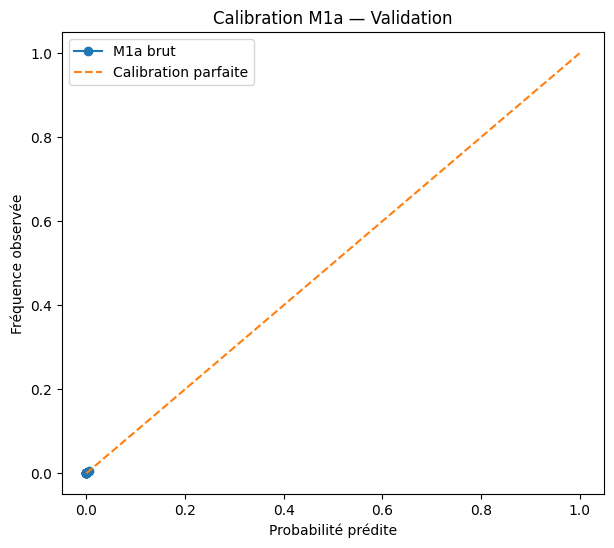

In [83]:
# Graphique
plt.figure(figsize=(7, 6))

plt.plot(
    prob_pred_raw,
    prob_true_raw,
    marker="o",
    label="M1a brut",
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Calibration parfaite",
)

plt.xlabel("Probabilité prédite")
plt.ylabel("Fréquence observée")
plt.title(
    "Calibration M1a — Validation"
)

plt.legend()
plt.show()

In [84]:
# Déterminer la frontière sur le volume uniquement
validation_volume_by_step = (
    validation.groupby("step")
    .size()
    .sort_index()
)

validation_cumulative = (
    validation_volume_by_step.cumsum()
    / validation_volume_by_step.sum()
)

calibration_split_step = (
    validation_cumulative
    .sub(0.60)
    .abs()
    .idxmin()
)

print(
    "Fin bloc calibration-fit :",
    calibration_split_step,
)

print(
    "Part cumulée :",
    validation_cumulative.loc[
        calibration_split_step
    ],
)

Fin bloc calibration-fit : 353
Part cumulée : 0.5987708963000735


In [85]:
# Construire les deux blocs
cal_fit_mask = (
    validation["step"]
    <= calibration_split_step
)

cal_eval_mask = (
    validation["step"]
    > calibration_split_step
)

y_cal_fit = y_val.loc[
    cal_fit_mask
]

y_cal_eval = y_val.loc[
    cal_eval_mask
]

score_cal_fit = m1a_score[
    cal_fit_mask.to_numpy()
]

score_cal_eval = m1a_score[
    cal_eval_mask.to_numpy()
]

In [86]:
# Contrôle
print("CALIBRATION FIT")
print(
    f"Transactions : "
    f"{len(y_cal_fit):,}"
)
print(
    f"Fraudes      : "
    f"{y_cal_fit.sum():,}"
)
print(
    f"Prévalence   : "
    f"{y_cal_fit.mean():.6%}"
)

print()

print("CALIBRATION EVAL")
print(
    f"Transactions : "
    f"{len(y_cal_eval):,}"
)
print(
    f"Fraudes      : "
    f"{y_cal_eval.sum():,}"
)
print(
    f"Prévalence   : "
    f"{y_cal_eval.mean():.6%}"
)

CALIBRATION FIT
Transactions : 564,814
Fraudes      : 300
Prévalence   : 0.053115%

CALIBRATION EVAL
Transactions : 378,475
Fraudes      : 260
Prévalence   : 0.068697%


In [87]:
# Calibrateur 1 : Platt / sigmoid
from sklearn.linear_model import LogisticRegression

# Fonction
def probability_to_logit(p):
    p = np.asarray(p, dtype=float)

    eps = 1e-7

    p = np.clip(
        p,
        eps,
        1 - eps,
    )

    return np.log(
        p / (1 - p)
    )

In [88]:
# Fit
platt = LogisticRegression(
    solver="lbfgs",
)

platt.fit(
    probability_to_logit(
        score_cal_fit
    ).reshape(-1, 1),
    y_cal_fit,
)

LogisticRegression()

In [89]:
# Probabilités sur le bloc d’évaluation
platt_eval = platt.predict_proba(
    probability_to_logit(
        score_cal_eval
    ).reshape(-1, 1)
)[:, 1]

In [90]:
# Calibrateur 2 : Isotonic Regression
from sklearn.isotonic import IsotonicRegression

# Fit
isotonic = IsotonicRegression(
    out_of_bounds="clip",
)

isotonic.fit(
    score_cal_fit,
    y_cal_fit,
)

isotonic_eval = isotonic.predict(
    score_cal_eval
)


In [91]:
# Comparaison brute / sigmoid / isotonic
calibration_comparison = pd.DataFrame({
    "methode": [
        "Brut",
        "Platt",
        "Isotonic",
    ],

    "brier": [
        brier_score_loss(
            y_cal_eval,
            score_cal_eval,
        ),

        brier_score_loss(
            y_cal_eval,
            platt_eval,
        ),

        brier_score_loss(
            y_cal_eval,
            isotonic_eval,
        ),
    ],

    "log_loss": [
        log_loss(
            y_cal_eval,
            score_cal_eval,
        ),

        log_loss(
            y_cal_eval,
            platt_eval,
        ),

        log_loss(
            y_cal_eval,
            isotonic_eval,
        ),
    ],

    "average_precision": [
        average_precision_score(
            y_cal_eval,
            score_cal_eval,
        ),

        average_precision_score(
            y_cal_eval,
            platt_eval,
        ),

        average_precision_score(
            y_cal_eval,
            isotonic_eval,
        ),
    ],
})

calibration_comparison

,methode,brier,log_loss,average_precision
0,Brut,0.000164,0.000557,0.907207
1,Platt,0.000164,0.000556,0.907207
2,Isotonic,0.000167,0.000758,0.876101


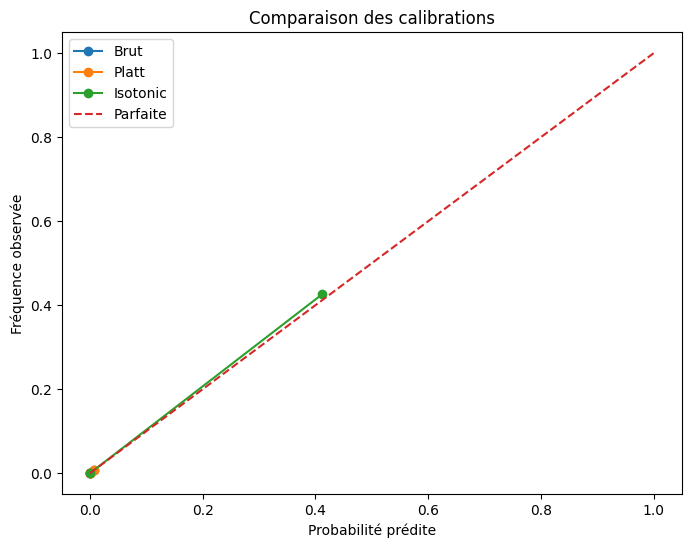

In [92]:
# Calibration curves comparées
plt.figure(figsize=(8, 6))

for label, probabilities in [
    (
        "Brut",
        score_cal_eval,
    ),
    (
        "Platt",
        platt_eval,
    ),
    (
        "Isotonic",
        isotonic_eval,
    ),
]:
    observed, predicted = (
        calibration_curve(
            y_cal_eval,
            probabilities,
            n_bins=10,
            strategy="quantile",
        )
    )

    plt.plot(
        predicted,
        observed,
        marker="o",
        label=label,
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Parfaite",
)

plt.xlabel("Probabilité prédite")
plt.ylabel("Fréquence observée")

plt.title(
    "Comparaison des calibrations"
)

plt.legend()
plt.show()

In [ ]:
# Au vue de ces résultats, Platt scaling est retenu comme couche de calibration finale.
# Il préserve le ranking et apporte une légère amélioration du Log Loss sans dégrader le Brier Score.
# Mais le gain étant très faible, la calibration ne doit pas être présentée comme une source majeure de performance.

In [93]:
# Réentraîner Platt sur toute Validation
final_platt = LogisticRegression(
    solver="lbfgs",
)

final_platt.fit(
    probability_to_logit(
        m1a_score
    ).reshape(-1, 1),
    y_val,
)

LogisticRegression()

In [94]:
# Sauvegarde de l’artefact probabiliste
ECONOMIC_MODEL_PATH = (
    MODELS_DIR
    / "economic_probability_v1.joblib"
)

economic_artifact = {
    "architecture": "M1a + Platt",
    "version": "1.0",

    "base_model": m1a,
    "calibrator": final_platt,

    "xgb_columns": list(
        X_train_xgb.columns
    ),

    "calibration_method": "platt",

    "train_steps": [1, 323],
    "calibration_steps": [324, 377],

    "notes": (
        "Probabilistic model for economic "
        "decision layer. Distinct from H2 "
        "ranking architecture."
    ),
}

joblib.dump(
    economic_artifact,
    ECONOMIC_MODEL_PATH,
)

['C:\\Users\\Emmanuel\\Documents\\Professionnel\\Formations\\DIT\\fraude-mobile-money\\models\\economic_probability_v1.joblib']

In [95]:
# Calcul de son SHA-256
economic_sha256 = sha256_file(
    ECONOMIC_MODEL_PATH
)

print(
    "Economic model SHA-256 :",
    economic_sha256,
)

Economic model SHA-256 : 77abc391b911c2c07e5b6c9410a0cd810ce898d887b4a8f3d99c929d4b6c16ed


In [100]:
# Recharge du nouveau scoring
import importlib
import src.scoring

importlib.reload(src.scoring)

from src.scoring import (
    exact_drain_mask,
    hybrid_priority_score,
    probability_to_logit,
    calibrated_fraud_probability,
)

print("src.scoring rechargé : OK")

src.scoring rechargé : OK


In [101]:
# Vérification : reproductibilité du modèle économique

# On Recharge l’artefact
loaded_economic = joblib.load(
    ECONOMIC_MODEL_PATH
)

loaded_base_model = (
    loaded_economic["base_model"]
)

loaded_calibrator = (
    loaded_economic["calibrator"]
)

economic_columns = (
    loaded_economic["xgb_columns"]
)

# On reconstruis Validation
X_val_economic = prepare_xgb_matrix(
    build_static_features(validation),
    train_columns=economic_columns,
)

X_val_economic = X_val_economic.reindex(
    columns=economic_columns,
    fill_value=0.0,
)

In [102]:
raw_probability_rebuilt = (
    loaded_base_model.predict_proba(
        X_val_economic
    )[:, 1]
)

calibrated_probability_rebuilt = (
    calibrated_fraud_probability(
        raw_probability_rebuilt,
        loaded_calibrator,
    )
)

In [103]:
# Contrôle
print(
    "Probability min :",
    calibrated_probability_rebuilt.min(),
)

print(
    "Probability max :",
    calibrated_probability_rebuilt.max(),
)

print(
    "Probability mean :",
    calibrated_probability_rebuilt.mean(),
)

print(
    "Observed prevalence :",
    y_val.mean(),
)

Probability min : 9.708045369586874e-08
Probability max : 0.999668004226833
Probability mean : 0.0006098383250771538
Observed prevalence : 0.00059366747624535


In [104]:
# Construire un scénario de référence
REFERENCE_SCENARIO = {
    "investigation_cost": 100.0,
    "loss_fraction": 1.0,
    "intervention_effectiveness": 0.8,
}

In [105]:
# Appliquer le scénario sur Validation
from src.policy import (
    expected_avoidable_loss,
    expected_net_value,
    economic_decision,
)

In [106]:
reference_cost = 100.0
reference_loss_fraction = 1.0
reference_effectiveness = 0.8

validation_economic = validation[
    [
        "step",
        "type",
        "amount",
        "is_fraud",
    ]
].copy()

validation_economic[
    "p_fraud"
] = calibrated_probability_rebuilt

In [107]:
# Calcul
validation_economic[
    "expected_avoidable_loss"
] = expected_avoidable_loss(
    probability=validation_economic["p_fraud"],
    amount=validation_economic["amount"],
    loss_fraction=reference_loss_fraction,
    intervention_effectiveness=reference_effectiveness,
)

validation_economic[
    "expected_net_value"
] = expected_net_value(
    probability=validation_economic["p_fraud"],
    amount=validation_economic["amount"],
    investigation_cost=reference_cost,
    loss_fraction=reference_loss_fraction,
    intervention_effectiveness=reference_effectiveness,
)

validation_economic[
    "review"
] = (
    validation_economic[
        "expected_net_value"
    ] > 0
)

In [108]:
# Évaluer la politique
review_mask = validation_economic[
    "review"
]

tp = int(
    validation_economic.loc[
        review_mask,
        "is_fraud"
    ].sum()
)

alerts = int(
    review_mask.sum()
)

total_frauds = int(
    validation_economic[
        "is_fraud"
    ].sum()
)

precision = (
    tp / alerts
    if alerts else 0.0
)

recall = (
    tp / total_frauds
    if total_frauds else 0.0
)

print(
    f"Alertes            : {alerts:,}"
)

print(
    f"Fraudes détectées  : {tp:,}"
)

print(
    f"Precision          : {precision:.2%}"
)

print(
    f"Recall             : {recall:.2%}"
)

Alertes            : 4,963
Fraudes détectées  : 558
Precision          : 11.24%
Recall             : 99.64%


In [109]:
# Mesurer une valeur économique observée
validation_economic[
    "realized_avoidable_loss"
] = (
    validation_economic["is_fraud"]
    * validation_economic["amount"]
    * reference_loss_fraction
    * reference_effectiveness
    * validation_economic["review"]
)

validation_economic[
    "realized_review_cost"
] = (
    reference_cost
    * validation_economic["review"]
)

In [110]:
total_avoidable = (
    validation_economic[
        "realized_avoidable_loss"
    ].sum()
)

total_review_cost = (
    validation_economic[
        "realized_review_cost"
    ].sum()
)

realized_net_value = (
    total_avoidable
    - total_review_cost
)

print(
    f"Pertes évitées simulées : "
    f"{total_avoidable:,.2f}"
)

print(
    f"Coût des contrôles      : "
    f"{total_review_cost:,.2f}"
)

print(
    f"Valeur nette simulée    : "
    f"{realized_net_value:,.2f}"
)

Pertes évitées simulées : 601,485,782.22
Coût des contrôles      : 496,300.00
Valeur nette simulée    : 600,989,482.22


In [111]:
# Analyse de sensibilité obligatoire
investigation_costs = [
    10,
    50,
    100,
    500,
    1_000,
]

effectiveness_values = [
    0.50,
    0.80,
    1.00,
]

loss_fraction_values = [
    0.50,
    1.00,
]

In [112]:
sensitivity_rows = []

for cost in investigation_costs:
    for effectiveness in effectiveness_values:
        for loss_fraction in loss_fraction_values:

            ev = expected_net_value(
                probability=calibrated_probability_rebuilt,
                amount=validation["amount"],
                investigation_cost=cost,
                loss_fraction=loss_fraction,
                intervention_effectiveness=effectiveness,
            )

            review = ev > 0

            alerts = int(
                review.sum()
            )

            tp = int(
                validation.loc[
                    review,
                    "is_fraud"
                ].sum()
            )

            precision = (
                tp / alerts
                if alerts else 0.0
            )

            recall = (
                tp / y_val.sum()
                if y_val.sum()
                else 0.0
            )

            realized_avoidable = (
                validation.loc[
                    review,
                    "is_fraud"
                ]
                * validation.loc[
                    review,
                    "amount"
                ]
                * loss_fraction
                * effectiveness
            ).sum()

            realized_cost = (
                alerts * cost
            )

            sensitivity_rows.append({
                "cost": cost,
                "effectiveness": effectiveness,
                "loss_fraction": loss_fraction,
                "alerts": alerts,
                "precision": precision,
                "recall": recall,
                "realized_avoidable_loss": realized_avoidable,
                "realized_review_cost": realized_cost,
                "realized_net_value": (
                    realized_avoidable
                    - realized_cost
                ),
            })

economic_sensitivity = pd.DataFrame(
    sensitivity_rows
)

economic_sensitivity

,cost,effectiveness,loss_fraction,alerts,precision,recall,realized_avoidable_loss,realized_review_cost,realized_net_value
0,10,0.5,0.5,12470,0.044908,1.000000,1.879643e+08,124700,1.878396e+08
1,10,0.5,1.0,20116,0.027839,1.000000,3.759287e+08,201160,3.757275e+08
2,10,0.8,0.5,17022,0.032899,1.000000,3.007429e+08,170220,3.005727e+08
3,10,0.8,1.0,27432,0.020414,1.000000,6.014859e+08,274320,6.012116e+08
4,10,1.0,0.5,20116,0.027839,1.000000,3.759287e+08,201160,3.757275e+08
5,10,1.0,1.0,30925,0.018108,1.000000,7.518574e+08,309250,7.515481e+08
6,50,0.5,0.5,3515,0.158179,0.992857,1.879642e+08,175750,1.877885e+08
7,50,0.5,1.0,5817,0.095926,0.996429,3.759286e+08,290850,3.756378e+08
8,50,0.8,0.5,4963,0.112432,0.996429,3.007429e+08,248150,3.004947e+08
9,50,0.8,1.0,8610,0.064925,0.998214,6.014858e+08,430500,6.010553e+08


In [ ]:
# Sous l’hypothèse illustrative d’une perte équivalente à 100 % du montant frauduleux, d’une efficacité d’intervention de 80 % et d’un coût de contrôle de 100 unités monétaires simulées, la politique présente une valeur nette rétrospective positive sur Validation.